# Figure 4

This notebook reproduces three plots. It uses only repository-relative paths and writes the figures to `data_analysis/outputs/figures/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
)
from sklearn.model_selection import StratifiedGroupKFold

plt.rcParams.update({
    'figure.dpi': 500,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
})

def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'data_analysis' / 'data' / 'analysis_data.xlsx').exists():
            return candidate
    raise FileNotFoundError('Could not locate data_analysis/data/analysis_data.xlsx.')

ROOT = find_repository_root()
DATA_FILE = ROOT / 'data_analysis' / 'data' / 'analysis_data.xlsx'
FIGURE_DIR = ROOT / 'data_analysis' / 'outputs' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
DROP_FEATURES = [
    'BB_conjugated_units_Norm_MolWt', 'R_ring_6',
    'Monomer_NumHDonors_Norm_MolWt', 'Monomer_NumHAcceptors_Norm_MolWt',
    'SC_atoms_before_plus_after_CO_Norm_MolWt', 'SideChain_Eccentricity',
    'Backbone_Eccentricity', 'Monomer_Eccentricity', 'R_atom_all',
    'SC_bonds_CC_or_CO_Norm_MolWt', 'BB_C_atoms_Norm_MolWt',
    'Backbone_InertialShapeFactor', 'Solvent_Eccentricity', 'Solvent_TPSA',
    'SideChain_TPSA', 'R_ring_3', 'R_ring_1',
    'SC_atoms_after_branching_CO_Norm_MolWt', 'Monomer_InertialShapeFactor',
    'SC_total_atoms_CO_Norm_MolWt', 'dG_solv_cosmo',
    'Monomer_NumSpiroAtoms_Norm_MolWt',
    'Monomer_NumSaturatedRings_Norm_MolWt',
    'Monomer_NumBridgeheadAtoms_Norm_MolWt', 'MW_Mw',
    'SC_C_atoms_Norm_MolWt', 'BB_CeqC_bonds_Norm_MolWt',
    'BB_CC_rotatable_bonds_Norm_MolWt', 'SC_total_branches_Norm_MolWt',
    'SC_atoms_before_branching_CO_Norm_MolWt', 'Backbone_TPSA',
    'BBminusSC_MolLogP', 'SideChain_InertialShapeFactor',
    'BB_rings_total_Norm_MolWt', 'Monomer_NumAromaticRings_Norm_MolWt',
    'SideChain_MolLogP',
]

feature_table = pd.read_excel(DATA_FILE, sheet_name='Exp_ML_features')
metadata_table = pd.read_excel(DATA_FILE, sheet_name='Exp_ML_metadata')
if not feature_table['experiment_id'].equals(metadata_table['experiment_id']):
    raise ValueError('Exp_ML_features and Exp_ML_metadata are not aligned by experiment_id.')
if feature_table['experiment_id'].duplicated().any():
    raise ValueError('Duplicate experiment_id values found.')

all_features_raw = feature_table.drop(columns='experiment_id')
all_labels = metadata_table.rename(columns={
    'family': 'Family', 'polymer': 'Polymer', 'solvent': 'Solvent'
}).copy()
all_labels['polymer_solvent_group'] = (
    all_labels['Polymer'].astype('string').str.replace(r'\s+', ' ', regex=True).str.lower()
    + ' || ' +
    all_labels['Solvent'].astype('string').str.replace(r'\s+', ' ', regex=True).str.lower()
)

base_mask = metadata_table['dataset_split'].eq('initial')
add_mask = metadata_table['dataset_split'].eq('additional')
if (int(base_mask.sum()), int(add_mask.sum())) != (717, 56):
    raise ValueError('Expected 717 initial and 56 additional experimental rows.')

base_features_raw = all_features_raw.loc[base_mask].reset_index(drop=True)
add_features_raw = all_features_raw.loc[add_mask].reset_index(drop=True)
base_labels_raw = all_labels.loc[base_mask, ['abs_g_factor']].reset_index(drop=True)
add_labels_raw = all_labels.loc[add_mask, ['abs_g_factor']].reset_index(drop=True)

base_features = base_features_raw.drop(columns=DROP_FEATURES, errors='ignore')
add_features = add_features_raw.drop(columns=DROP_FEATURES, errors='ignore')
base_labels = all_labels.loc[base_mask].reset_index(drop=True)
add_labels = all_labels.loc[add_mask].reset_index(drop=True)
full_features = pd.concat([base_features, add_features], ignore_index=True)
full_labels = pd.concat([base_labels, add_labels], ignore_index=True)

print(f'Initial dataset: {len(base_features)} rows, {base_features.shape[1]} model features')
print(f'Full dataset: {len(full_features)} rows, {full_features.shape[1]} model features')


Initial dataset: 717 rows, 41 model features
Full dataset: 773 rows, 41 model features


## Figure 4b — distribution of $|g|$

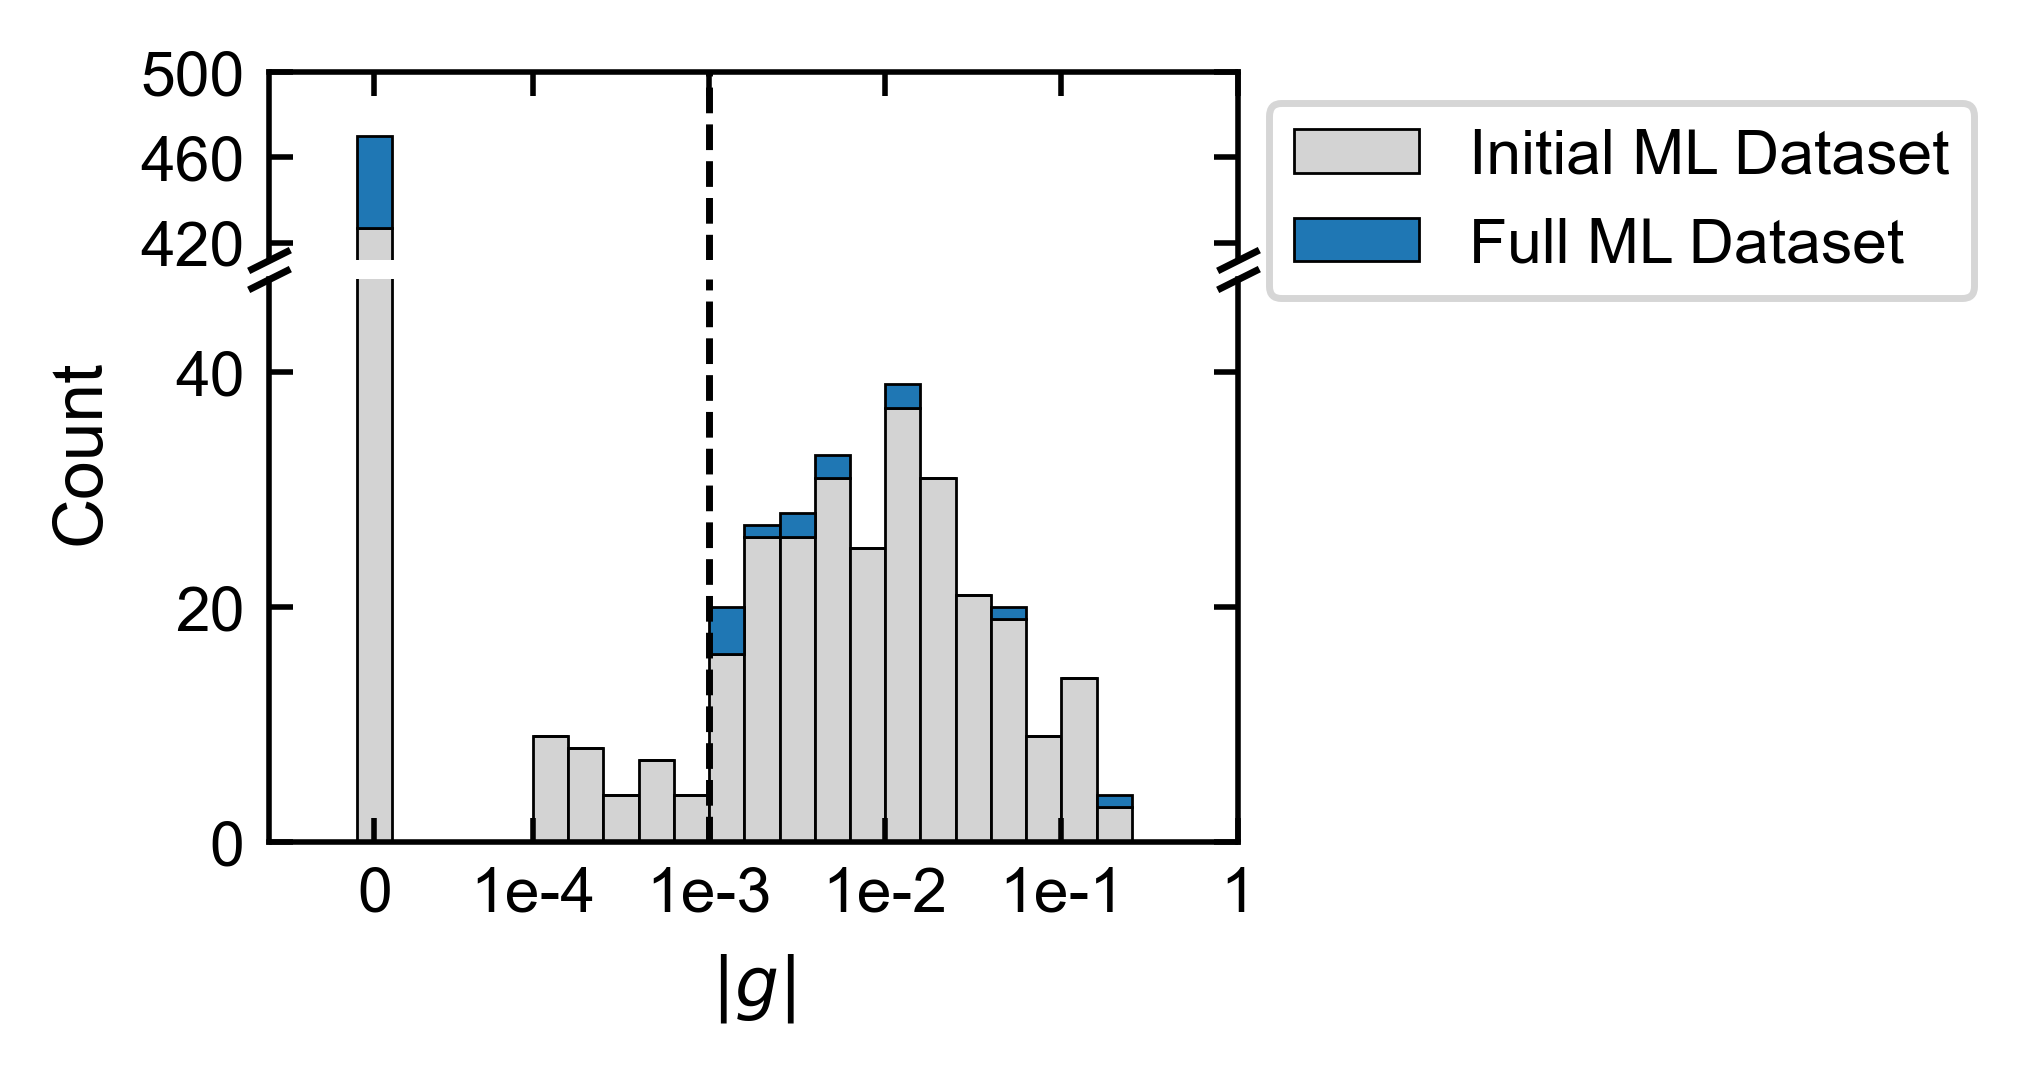

In [3]:
base_g = pd.to_numeric(base_labels_raw['abs_g_factor'], errors='coerce').dropna().to_numpy(float)
added_g = pd.to_numeric(add_labels_raw['abs_g_factor'], errors='coerce').dropna().to_numpy(float)
base_g[base_g == 0] = 1e-5
added_g[added_g == 0] = 1e-5

base_counts, edges = np.histogram(np.log10(base_g), bins=30, range=(-6, 0))
added_counts, _ = np.histogram(np.log10(added_g), bins=edges)
bin_lefts, bin_widths = edges[:-1], np.diff(edges)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(2.5, 2),
    gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05},
)
for ax in (ax_top, ax_bot):
    ax.bar(bin_lefts, base_counts, width=bin_widths, align='edge',
           color='lightgray', edgecolor='black', linewidth=0.4, label='Initial ML Dataset')
    ax.bar(bin_lefts, added_counts, width=bin_widths, align='edge', bottom=base_counts,
           color='C0', edgecolor='black', linewidth=0.4, label='Full ML Dataset')
    ax.axvline(-3, color='black', linestyle='dashed', linewidth=1)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax_bot.set_ylim(0, 48)
ax_bot.set_yticks([0, 20, 40])
ax_top.set_ylim(412, 500)
ax_top.set_yticks([420, 460, 500])
ax_bot.tick_params(axis='y', labelsize=9)
ax_top.tick_params(axis='y', labelsize=9)
ax_bot.set_xlim(-5.5, 0)
ax_bot.set_xticks([-4.9, -4, -3, -2, -1, 0], ['0', '1e-4', '1e-3', '1e-2', '1e-1', '1'], fontsize=9)
ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.xaxis.tick_top()
ax_bot.xaxis.tick_bottom()

break_mark = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=6, linestyle='none',
                  color='black', mec='black', mew=1, clip_on=False)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **break_mark)
ax_bot.plot([0, 1], [1, 1], transform=ax_bot.transAxes, **break_mark)
ax_bot.set_xlabel(r'$|g|$', fontsize=10)
fig.supylabel('Count', x=-0.05, fontsize=10)
ax_top.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
fig.savefig(FIGURE_DIR / 'Figure4b.png', dpi=500, bbox_inches='tight')
plt.show()


## Figure 4c — grouped out-of-fold precision–recall curves

In [4]:
CLASSIFIER_PARAMS = {
    'n_estimators': 1100, 'max_depth': 12, 'min_samples_leaf': 2,
    'min_samples_split': 2, 'max_features': 0.5,
    'class_weight': 'balanced', 'bootstrap': True, 'n_jobs': -1,
}
RECALL_GRID = np.linspace(0, 1, 201)
N_SPLITS = 5
N_REPEATS = 20

def interpolate_pr(y_true, y_score):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    unique_curve = (
        pd.DataFrame({'recall': recall[::-1], 'precision': precision[::-1]})
        .groupby('recall', as_index=False)['precision'].max()
    )
    interpolated = np.interp(RECALL_GRID, unique_curve['recall'], unique_curve['precision'])
    return interpolated, average_precision_score(y_true, y_score)

def repeated_grouped_pr(features, labels, name):
    X = features.select_dtypes(include=[np.number]).copy()
    g = pd.to_numeric(labels['abs_g_factor'], errors='coerce')
    groups = labels['polymer_solvent_group']
    valid = g.notna() & groups.notna()
    X = X.loc[valid].reset_index(drop=True)
    y = (g.loc[valid] >= 0.001).astype(int).reset_index(drop=True).to_numpy()
    groups = groups.loc[valid].reset_index(drop=True).to_numpy()
    X = X.to_numpy(dtype=float)

    curves, scores = [], []
    for repeat in range(N_REPEATS):
        seed = 1000 + repeat
        cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
        oof_probability = np.full(len(y), np.nan)
        for fold, (train_index, test_index) in enumerate(cv.split(X, y, groups), start=1):
            if set(groups[train_index]).intersection(groups[test_index]):
                raise RuntimeError('Polymer-solvent group leakage detected.')
            model = RandomForestClassifier(
                **CLASSIFIER_PARAMS, random_state=seed * 100 + fold
            )
            model.fit(X[train_index], y[train_index])
            oof_probability[test_index] = model.predict_proba(X[test_index])[:, 1]
        if not np.isfinite(oof_probability).all():
            raise RuntimeError('Incomplete OOF classification predictions.')
        curve, score = interpolate_pr(y, oof_probability)
        curves.append(curve)
        scores.append(score)
        print(f'{name}: repeat {repeat + 1:02d}/{N_REPEATS}, AP={score:.4f}', flush=True)

    curves = np.asarray(curves)
    scores = np.asarray(scores)
    mean, std = curves.mean(axis=0), curves.std(axis=0)
    return {
        'mean': mean, 'lower': np.clip(mean - std, 0, 1),
        'upper': np.clip(mean + std, 0, 1), 'ap': scores,
        'baseline': y.mean(),
    }

base_pr = repeated_grouped_pr(base_features, base_labels, 'Initial dataset')
full_pr = repeated_grouped_pr(full_features, full_labels, 'Full dataset')


Initial dataset: repeat 01/20, AP=0.7963


Initial dataset: repeat 02/20, AP=0.7885


Initial dataset: repeat 03/20, AP=0.7290


Initial dataset: repeat 04/20, AP=0.7741


Initial dataset: repeat 05/20, AP=0.7724


...

Full dataset: repeat 16/20, AP=0.8186


Full dataset: repeat 17/20, AP=0.7853


Full dataset: repeat 18/20, AP=0.8125


Full dataset: repeat 19/20, AP=0.7977


Full dataset: repeat 20/20, AP=0.8022


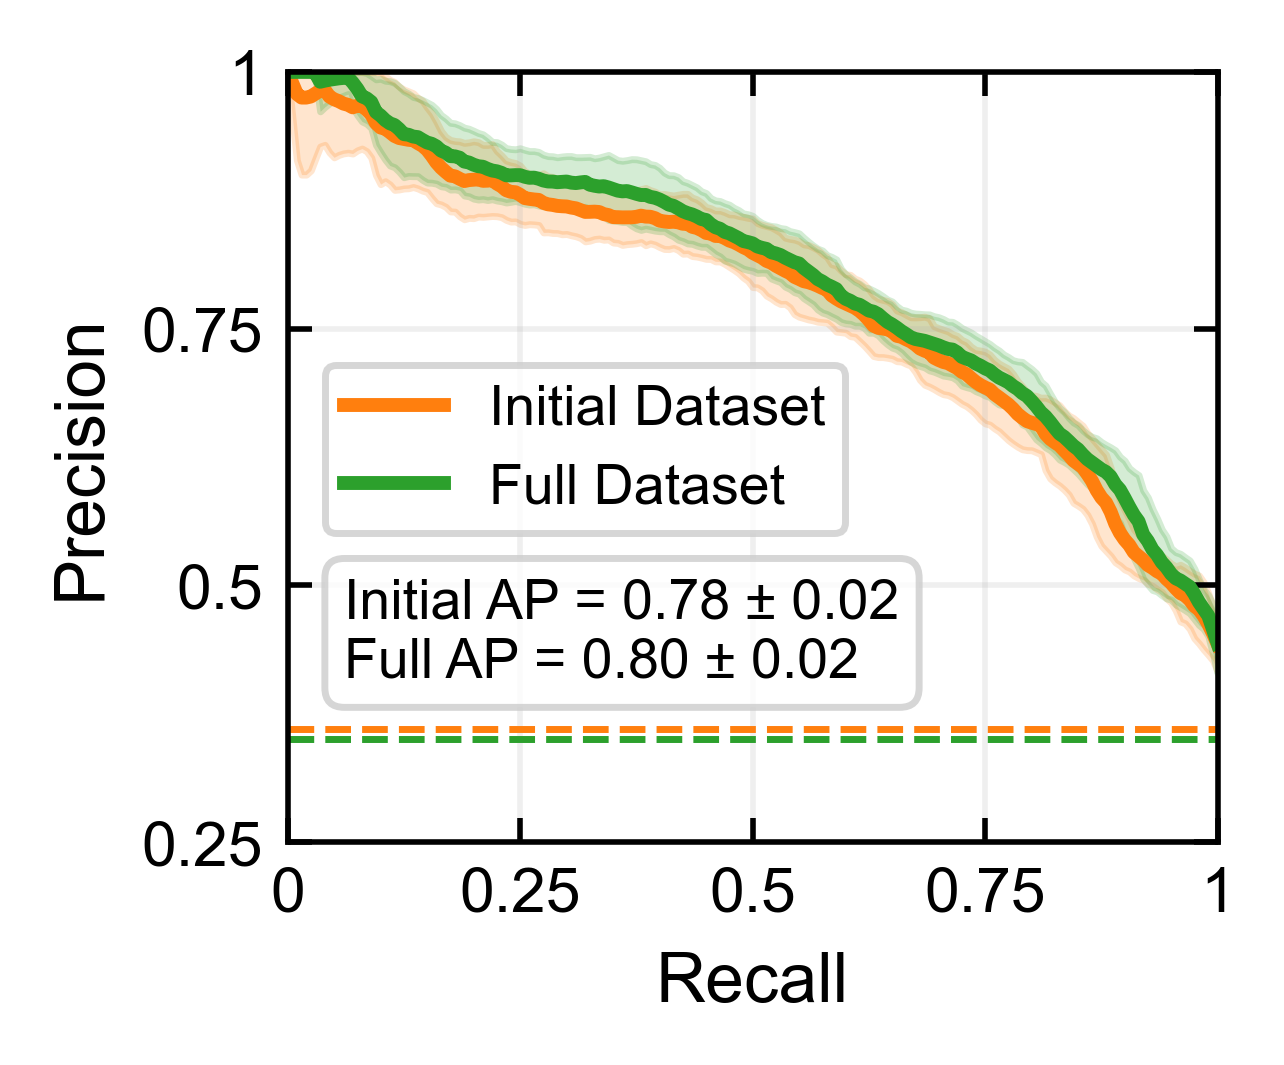

Initial dataset OOF AP: 0.7809 ± 0.0190
Full dataset OOF AP: 0.7965 ± 0.0158


In [5]:
fig, ax = plt.subplots(figsize=(2.4, 2))
ax.plot(RECALL_GRID, base_pr['mean'], lw=2, label='Initial Dataset', color='C1')
ax.fill_between(RECALL_GRID, base_pr['lower'], base_pr['upper'], alpha=0.20, color='C1')
ax.plot(RECALL_GRID, full_pr['mean'], lw=2, label='Full Dataset', color='C2')
ax.fill_between(RECALL_GRID, full_pr['lower'], full_pr['upper'], alpha=0.20, color='C2')
ax.axhline(base_pr['baseline'], linestyle='--', color='C1', lw=1)
ax.axhline(full_pr['baseline'], linestyle='--', color='C2', lw=1)

legend = ax.legend(
    fontsize=8, loc='upper left', bbox_to_anchor=(0.04, 0.62),
    borderaxespad=0, frameon=True, fancybox=True, framealpha=0.8,
    borderpad=0.35, handlelength=1.8, handletextpad=0.8,
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('0.8')
legend.get_frame().set_linewidth(1.0)

base_text = f"{base_pr['ap'].mean():.2f} ± {base_pr['ap'].std():.2f}"
full_text = f"{full_pr['ap'].mean():.2f} ± {full_pr['ap'].std():.2f}"
ax.text(
    0.061, 0.20, f'Initial AP = {base_text}\nFull AP = {full_text}',
    transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
              edgecolor='0.8', linewidth=1.0, alpha=0.8),
)
ax.set_xlabel('Recall', fontsize=10)
ax.set_ylabel('Precision', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0.25, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75, 1], [0.25, 0.5, 0.75, 1], fontsize=9)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.grid(alpha=0.2)
fig.savefig(FIGURE_DIR / 'Figure4c.png', dpi=500, bbox_inches='tight')
plt.show()
print(f"Initial dataset OOF AP: {base_pr['ap'].mean():.4f} ± {base_pr['ap'].std():.4f}")
print(f"Full dataset OOF AP: {full_pr['ap'].mean():.4f} ± {full_pr['ap'].std():.4f}")


## Figure 4d — grouped out-of-fold regression parity plot

In [6]:
REGRESSOR_PARAMS = {
    'criterion': 'squared_error', 'n_estimators': 1500, 'max_depth': 20,
    'max_features': 'log2', 'min_samples_split': 30,
    'min_samples_leaf': 36, 'max_samples': 0.7, 'bootstrap': True,
}

g = pd.to_numeric(base_labels['abs_g_factor'], errors='coerce')
groups = base_labels['polymer_solvent_group']
valid = g.notna() & (g >= 0.001) & groups.notna()
X_reg = base_features.select_dtypes(include=[np.number]).loc[valid].reset_index(drop=True)
y_reg = np.log10(g.loc[valid].reset_index(drop=True).to_numpy(float))
groups_reg = groups.loc[valid].reset_index(drop=True).to_numpy()
if np.isinf(X_reg.to_numpy(float)).any():
    raise ValueError('Regression features contain infinite values.')

strata = pd.qcut(pd.Series(y_reg), q=5, labels=False, duplicates='drop').astype(int).to_numpy()
predictions = np.zeros((N_REPEATS, len(y_reg)), dtype=float)
repeat_metrics = []

for repeat in range(N_REPEATS):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42 + repeat)
    prediction = np.full(len(y_reg), np.nan)
    for fold, (train_index, test_index) in enumerate(
        cv.split(X_reg, strata, groups=groups_reg), start=1
    ):
        if set(groups_reg[train_index]).intersection(groups_reg[test_index]):
            raise RuntimeError('Polymer-solvent group leakage detected.')
        model = RandomForestRegressor(
            **REGRESSOR_PARAMS, random_state=1000 * repeat + fold, n_jobs=-1
        )
        model.fit(X_reg.iloc[train_index], y_reg[train_index])
        prediction[test_index] = model.predict(X_reg.iloc[test_index])
    if not np.isfinite(prediction).all():
        raise RuntimeError('Incomplete OOF regression predictions.')
    predictions[repeat] = prediction
    repeat_metrics.append({
        'r2': r2_score(y_reg, prediction),
        'mae': mean_absolute_error(y_reg, prediction),
        'rmse': np.sqrt(mean_squared_error(y_reg, prediction)),
    })
    print(f'Regression: repeat {repeat + 1:02d}/{N_REPEATS}', flush=True)

regression_metrics = pd.DataFrame(repeat_metrics)
y_pred_mean = predictions.mean(axis=0)
y_pred_std = predictions.std(axis=0)


Regression: repeat 01/20


Regression: repeat 02/20


Regression: repeat 03/20


Regression: repeat 04/20


Regression: repeat 05/20


...

Regression: repeat 16/20


Regression: repeat 17/20


Regression: repeat 18/20


Regression: repeat 19/20


Regression: repeat 20/20


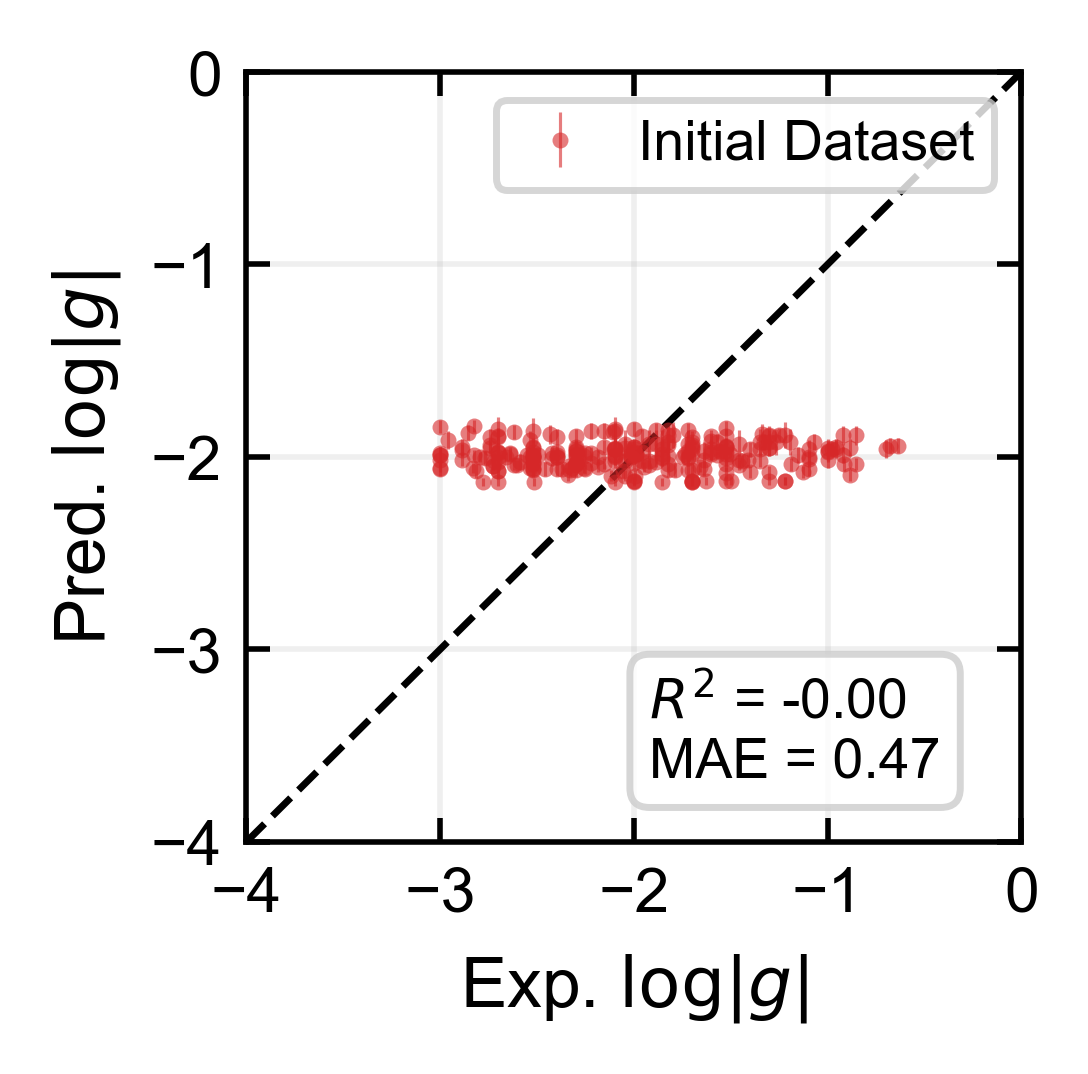

OOF mean-prediction R2: -0.0008
OOF mean-prediction MAE: 0.4710
OOF mean-prediction RMSE: 0.5663

Repeat-level OOF metrics:
R2: -0.0052 ± 0.0278
MAE: 0.4719 ± 0.0062
RMSE: 0.5675 ± 0.0078


In [7]:
r2_plot = r2_score(y_reg, y_pred_mean)
mae_plot = mean_absolute_error(y_reg, y_pred_mean)
rmse_plot = np.sqrt(mean_squared_error(y_reg, y_pred_mean))

fig, ax = plt.subplots(figsize=(2, 2))
ax.errorbar(
    y_reg, y_pred_mean, yerr=y_pred_std, fmt='o', color='C3', ecolor='C3',
    label='Initial Dataset', markersize=2.3, alpha=0.60,
    elinewidth=0.45, capsize=0, markeredgewidth=0, linewidth=0,
)
ax.plot([-4, 0], [-4, 0], '--', color='black', lw=1)
ax.set_xlabel(r'Exp. $\log|g|$', fontsize=10)
ax.set_ylabel(r'Pred. $\log|g|$', fontsize=10)
ax.set_xlim(-4, 0)
ax.set_ylim(-4, 0)
legend = ax.legend(
    fontsize=8, loc='upper right', frameon=True, fancybox=True,
    framealpha=0.8, borderpad=0.35, handlelength=1.6, handletextpad=0.6,
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('0.8')
legend.get_frame().set_linewidth(1.0)
ax.text(
    0.52, 0.07, rf'$R^2$ = {r2_plot:.2f}' + '\n' + rf'MAE = {mae_plot:.2f}',
    transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
              edgecolor='0.8', linewidth=1.0, alpha=0.8),
)
ax.set_xticks([-4, -3, -2, -1, 0])
ax.set_yticks([-4, -3, -2, -1, 0])
ax.tick_params(axis='both', labelsize=9)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.grid(alpha=0.2)
fig.savefig(FIGURE_DIR / 'Figure4d.png', dpi=500, bbox_inches='tight')
plt.show()
print(f'OOF mean-prediction R2: {r2_plot:.4f}')
print(f'OOF mean-prediction MAE: {mae_plot:.4f}')
print(f'OOF mean-prediction RMSE: {rmse_plot:.4f}')
print('\nRepeat-level OOF metrics:')
for metric in ['r2', 'mae', 'rmse']:
    print(f'{metric.upper()}: {regression_metrics[metric].mean():.4f} ± {regression_metrics[metric].std(ddof=0):.4f}')
